# Testing Noise Model On ***Bit Flip*** Error Correction Code

In [56]:
# Typical imports

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('dark_background')    # Use dark background for plots

import qibo
assert qibo.__version__ >= "0.2.20", "This script requires qibo version 0.2.20 or higher."

from qibo import Circuit, gates
from qibo.result import CircuitResult
from qibo.gates import *

from qibo.ui import plot_circuit, plot_density_hist, visualize_state
from qibo.ui.drawing_utils import QIBO_COMPLEMENTARY_COLOR, QIBO_DEFAULT_COLOR, generate_bitstring_combinations

### Import QEC module ###
from qibo_qec import QEC

custom_style = {                    # Define a custom style for the circuit plot
    "facecolor" : "#000000",
    "edgecolor" : "#ffffff",
    "linecolor" : "#ffffff",
    "textcolor" : "#ffffff",
    "fillcolor" : "#c41b1b",
    "gatecolor" : "#9000ff",
    "controlcolor" : "#360000"
}

def fidelity(dm1, dm2, n=3):
    """Compute the fidelity between two density matrices."""
    sqrt_dm1 = np.sqrt(dm1)
    return round(np.real(np.square(np.trace( np.sqrt( sqrt_dm1 @ dm2 @ sqrt_dm1 ) ))), n)

Importing Noise Model from Qibo

In [57]:
from qibo.noise import NoiseModel, PauliError

## Compare Noise with and without Error Correction

Define noise model with Bit Flip Error as a Pauli X gate with certain error probability

Apply noise model to the circuits

Initialized QEC with code type: bit_flip


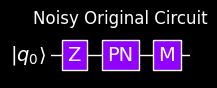

Applying bit_flip code to a circuit with 3 qubit(s).


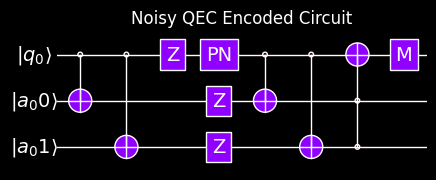

In [58]:
# Create a QEC object for Bit-Flip code
qec = QEC(code_type="bit_flip")

# Define a simple circuit
qc = Circuit(1, density_matrix=True)
qc.add( [ gates.Z(0), gates.M(0)] )

# Probability of bit-flip error
error_rate = 0.2
# Define noise model with Bit Flip Error as a Pauli X gate with certain error probability
noise_model = NoiseModel()
noise_model.add(PauliError([("X", error_rate)]), gates.Z, 0)

# Apply noise model to original and QEC encoded circuits
qc_noisy = noise_model.apply(qc)
plot_circuit(qc_noisy, style=custom_style)
plt.title("Noisy Original Circuit")
plt.show()

qc_qec = qec.apply_code(qc)
qc_qec_noisy = noise_model.apply(circuit=qc_qec)
plot_circuit(qc_qec_noisy, style=custom_style)
plt.title("Noisy QEC Encoded Circuit")
plt.show()

## Simulated Ideal Circuit with no Noise

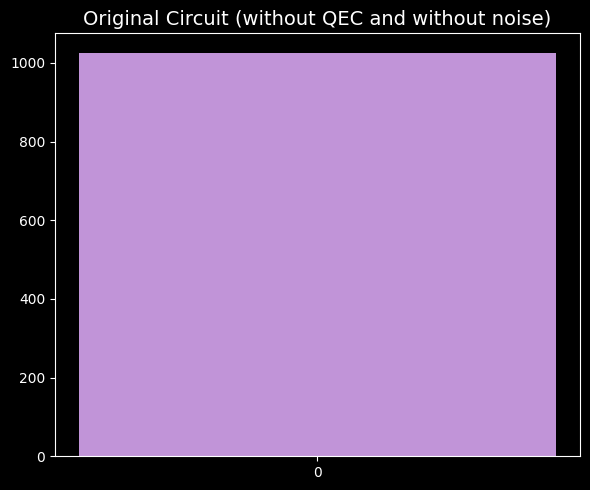

In [59]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax.set_title("Original Circuit (without QEC and without noise)", fontsize=14)
result_og = qc(nshots=2**10, noise_model=None)
ax.bar(result_og.frequencies().keys(), result_og.frequencies().values(), color=QIBO_DEFAULT_COLOR)
plt.tight_layout()
plt.show()

Simulated Circuit with Noise

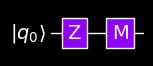

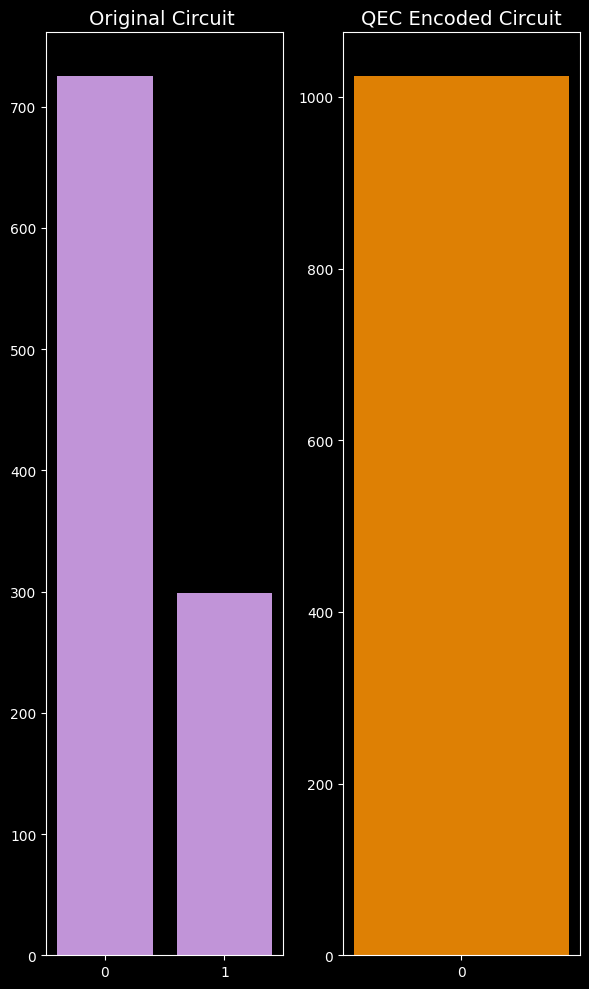

In [90]:
qc = Circuit(1)
qc.add( [ gates.Z(0), gates.M(0)] )
plot_circuit(qc, style=custom_style)

# Create Noise Model
noise_model = NoiseModel()
noise_model.add(PauliError([("X", 0.3)]), gates.Z, [0])


qc_noisy = noise_model.apply(qc)
result = qc_noisy(nshots=2**10)


# Apply noise model to QEC encoded circuit
qc_qec_noisy = noise_model.apply(circuit=qc_qec)

result_qec = qc_qec_noisy(nshots=2**10)

fig,ax = plt.subplots(1,2, figsize=(6,10))

ax[0].bar(result.frequencies().keys(), result.frequencies().values(), color=QIBO_DEFAULT_COLOR)
ax[0].set_title("Original Circuit ", fontsize=14)
ax[1].bar(result_qec.frequencies().keys(), result_qec.frequencies().values(), color=QIBO_COMPLEMENTARY_COLOR)
ax[1].set_title("QEC Encoded Circuit", fontsize=14)
plt.tight_layout()
plt.show()


## Conclusion:

The 3 qubit Bit-Flip code is able to correct error up to 1 error per logical qubit.

## Fidelity over error rate on ALL Qubits

(<Axes: >, <Figure size 120x60 with 1 Axes>)

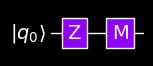

In [81]:
qc = Circuit(1, density_matrix=True)
qc.add( [ gates.Z(0), gates.M(0)] )

plot_circuit(qc, style=custom_style)

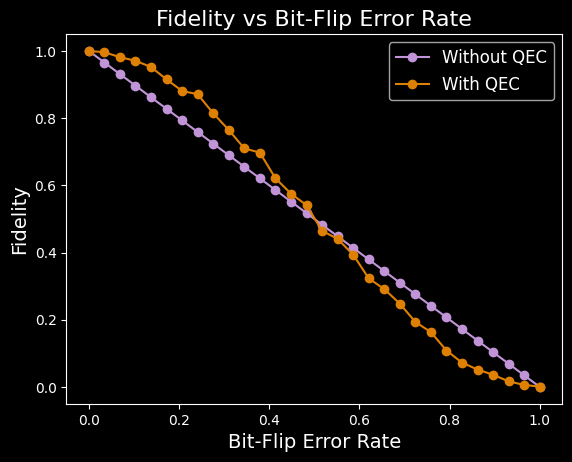

In [ ]:
ranges = np.linspace(0, 1, 30)

fidelitys_no_qec = []
fidelitys_qec = []

for i in ranges:

    # Define noise model with Bit Flip Error as a Pauli X gate with certain error probability
    noise_model = NoiseModel()
    noise_model.add(PauliError([("X", i)]), gates.Z, [0,1,2])
    
    qc_noisy = noise_model.apply(qc)
    result = qc_noisy(nshots=2**10)

    fidelitys_no_qec.append( result.probabilities()[0] )

    # Apply noise model to QEC encoded circuit
    qc_qec_noisy = noise_model.apply(circuit=qc_qec)
    
    result_qec = qc_qec_noisy(nshots=2**10)

    fidelitys_qec.append( result_qec.probabilities()[0] )

    # print("Fidelities :", result.probabilities()[0], result_qec.probabilities()[0])

plt.title("Fidelity vs Bit-Flip Error Rate", fontsize=16)
plt.plot(ranges, fidelitys_no_qec, label="Without QEC", color=QIBO_DEFAULT_COLOR, marker='o')
plt.plot(ranges, fidelitys_qec, label="With QEC", color=QIBO_COMPLEMENTARY_COLOR, marker='o')
plt.xlabel("Bit-Flip Error Rate", fontsize=14)
plt.ylabel("Fidelity", fontsize=14)
plt.legend(fontsize=12)
plt.show()